In [77]:
import pandas as pd
import numpy as np
#1

df = pd.read_csv('catalog_products.csv')

print(f"Форма DataFrame:{df.shape}")
print(f"Типы данных: \n{df.dtypes.to_string()}")
print(f"Пропуски: \n{df.isnull().sum().to_string()}")
print(f"Первые 5 строк:{df.head()}")

Форма DataFrame:(10000, 50)
Типы данных: 
col_1       str
col_2     int64
col_3     int64
col_4       str
col_5     int64
col_6     int64
col_7       str
col_8     int64
col_9     int64
col_10      str
col_11    int64
col_12    int64
col_13      str
col_14    int64
col_15    int64
col_16      str
col_17    int64
col_18    int64
col_19      str
col_20    int64
col_21    int64
col_22      str
col_23    int64
col_24    int64
col_25      str
col_26    int64
col_27    int64
col_28      str
col_29    int64
col_30    int64
col_31      str
col_32    int64
col_33    int64
col_34      str
col_35    int64
col_36    int64
col_37      str
col_38    int64
col_39    int64
col_40      str
col_41    int64
col_42    int64
col_43      str
col_44    int64
col_45    int64
col_46      str
col_47    int64
col_48    int64
col_49      str
col_50    int64
Пропуски: 
col_1     0
col_2     0
col_3     0
col_4     0
col_5     0
col_6     0
col_7     0
col_8     0
col_9     0
col_10    0
col_11    0
col_12    0
col

In [78]:
#2
for col in df.columns:
    temp_col = pd.to_numeric(df[col],errors='coerce')
    if not temp_col.isna().all():
        df[col] = temp_col.astype(float)
        mean_val = df[col].mean()
        df[col] = df[col].fillna(mean_val)
numeric_cols = df.select_dtypes(include=['float64']).columns
print("Пропуски в числовых колонках после заполнения:")
print(df[numeric_cols].isnull().sum())

Пропуски в числовых колонках после заполнения:
col_2     0
col_3     0
col_5     0
col_6     0
col_8     0
col_9     0
col_11    0
col_12    0
col_14    0
col_15    0
col_17    0
col_18    0
col_20    0
col_21    0
col_23    0
col_24    0
col_26    0
col_27    0
col_29    0
col_30    0
col_32    0
col_33    0
col_35    0
col_36    0
col_38    0
col_39    0
col_41    0
col_42    0
col_44    0
col_45    0
col_47    0
col_48    0
col_50    0
dtype: int64


In [79]:
#3
df['total_value'] = df['col_2'] * df['col_3']
df['double_stock'] = df['col_4'] * 2
df['log_price'] = np.log(df['col_2'])
print(df[['col_2','col_3','col_4','total_value','double_stock','log_price']].head())

   col_2  col_3        col_4  total_value            double_stock  log_price
0  762.0  303.0  Electronics     230886.0  ElectronicsElectronics   6.635947
1  190.0   34.0       Sports       6460.0            SportsSports   5.247024
2  711.0    2.0         Home       1422.0                HomeHome   6.566672
3  484.0  362.0        Books     175208.0              BooksBooks   6.182085
4  733.0  195.0         Home     142935.0                HomeHome   6.597146


In [80]:
#4
electronic_expensive = df[(df['col_2'] > 500) & (df['col_7'] == 'Electronics')]
print(electronic_expensive.head())

          col_1  col_2  col_3        col_4  col_5  col_6        col_7  col_8  \
10         Home  605.0  250.0         Home  927.0  617.0  Electronics  506.0   
16         Home  670.0  334.0  Electronics  548.0  396.0  Electronics  994.0   
63     Clothing  926.0   35.0         Home  138.0  312.0  Electronics  197.0   
66     Clothing  716.0  813.0        Books  794.0  346.0  Electronics  448.0   
70  Electronics  937.0  526.0     Clothing  987.0  507.0  Electronics  421.0   

    col_9    col_10  ...  col_44  col_45       col_46  col_47  col_48  \
10  793.0  Clothing  ...   397.0   950.0       Sports   354.0   991.0   
16  942.0     Books  ...   277.0   250.0  Electronics   374.0   801.0   
63  966.0      Home  ...    30.0   956.0     Clothing   658.0   141.0   
66  870.0      Home  ...   756.0   593.0       Sports   840.0   627.0   
70  905.0     Books  ...   104.0    38.0     Clothing   499.0   265.0   

      col_49  col_50  total_value            double_stock  log_price  
10     Bo

In [81]:
#5
category_stats = df.groupby('col_7').agg(
    mean_price = ('col_2','mean'),
    max_price = ('col_2','max'),
    total_quantity = ('col_3','sum')
).reset_index()
category_stats = category_stats.rename(columns = {'col_7':'category'})
display(category_stats)

,category,mean_price,max_price,total_quantity
0,Books,494.009027,999.0,982076.0
1,Clothing,495.738608,999.0,1008454.0
2,Electronics,505.886228,999.0,1009669.0
3,Home,511.097561,999.0,995489.0
4,Sports,509.046637,999.0,1008988.0


In [82]:
#6
numeric_cols = [f'col_{i}' for i in range(2,12)]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

result = (
    df[numeric_cols]
    .agg(['mean','median','std'])
    .T
    .reset_index()
    .rename(columns = {'index':'column'})
)
display(result)

,column,mean,median,std
0,col_2,503.1608,509.0,289.808030
1,col_3,500.4676,502.5,288.052132
2,col_4,NaN,NaN,NaN
3,col_5,494.9370,493.0,290.634660
4,col_6,500.0842,502.0,287.772049
5,col_7,NaN,NaN,NaN
6,col_8,500.1320,498.0,287.280092
7,col_9,494.8945,488.0,288.756643
8,col_10,NaN,NaN,NaN
9,col_11,499.8112,501.0,287.426535


In [83]:
#7
mean_price = df['col_2'].mean()
std_price = df['col_2'].std()

upper_limit = mean_price + 3*std_price

anomalies = df[df['col_2'] > upper_limit]
print(f"Средняя цена {mean_price:.2f}")
print(f"Стандартное отклонение {std_price:.2f}")
print(f"Граница аномалий {upper_limit:.2f}")
print(f"Количество найденных аномалии {len(anomalies)}")
display(anomalies.head())

Средняя цена 503.16
Стандартное отклонение 289.81
Граница аномалий 1372.58
Количество найденных аномалии 0


,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,...,col_44,col_45,col_46,col_47,col_48,col_49,col_50,total_value,double_stock,log_price


In [84]:
#8
target_cols = [f'col_{i}'for i in range(2,12)]

numeric_df = df[target_cols].apply(pd.to_numeric,errors='coerce')

correlation_matrix = numeric_df.corr()
print("Корреляционная функция:")
print(correlation_matrix)

Корреляционная функция:
           col_2     col_3  col_4     col_5     col_6  col_7     col_8  \
col_2   1.000000 -0.006128    NaN -0.002368 -0.004579    NaN  0.019838   
col_3  -0.006128  1.000000    NaN  0.020303  0.004545    NaN  0.014136   
col_4        NaN       NaN    NaN       NaN       NaN    NaN       NaN   
col_5  -0.002368  0.020303    NaN  1.000000  0.022725    NaN  0.015310   
col_6  -0.004579  0.004545    NaN  0.022725  1.000000    NaN -0.005012   
col_7        NaN       NaN    NaN       NaN       NaN    NaN       NaN   
col_8   0.019838  0.014136    NaN  0.015310 -0.005012    NaN  1.000000   
col_9  -0.008986  0.004623    NaN  0.013237  0.002743    NaN -0.008199   
col_10       NaN       NaN    NaN       NaN       NaN    NaN       NaN   
col_11 -0.006885  0.002812    NaN -0.000047 -0.019907    NaN  0.002730   

           col_9  col_10    col_11  
col_2  -0.008986     NaN -0.006885  
col_3   0.004623     NaN  0.002812  
col_4        NaN     NaN       NaN  
col_5   0.013

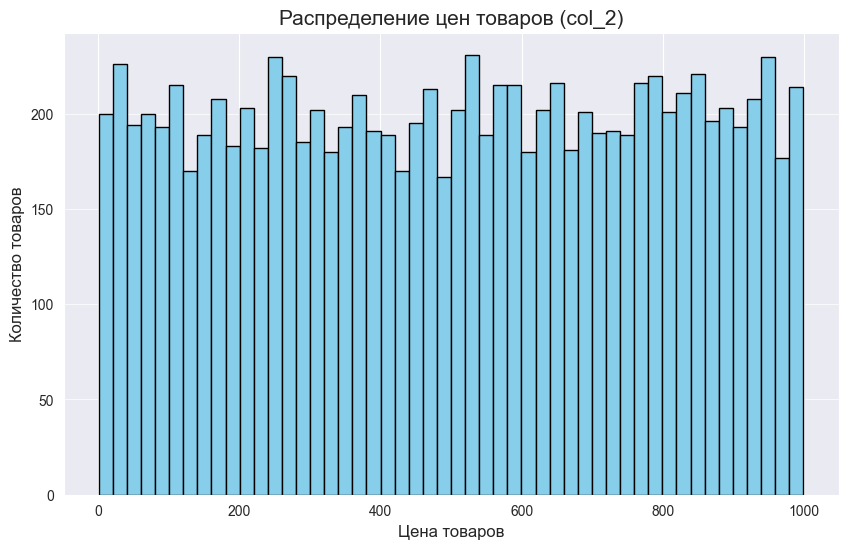

In [85]:
import matplotlib.pyplot as plt
#9
plt.figure(figsize=(10, 6))
plt.hist(df['col_2'], bins=50, color='skyblue', edgecolor='black')

plt.title('Распределение цен товаров (col_2)', fontsize=15)
plt.xlabel('Цена товаров', fontsize=12)
plt.ylabel('Количество товаров', fontsize=12)

plt.grid(axis='y', alpha=0.75)
plt.show()

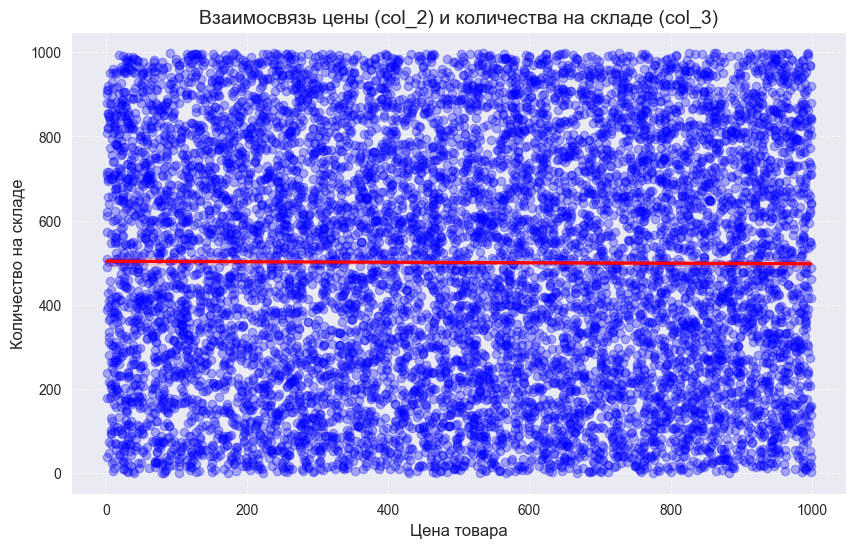

In [86]:
import seaborn as sns
#10
plt.figure(figsize=(10,6))

sns.regplot(data=df, x='col_2', y='col_3',
            scatter_kws={'alpha':0.3,'color':'blue'},
            line_kws={'color':'red'})

plt.title('Взаимосвязь цены (col_2) и количества на складе (col_3)', fontsize=14)
plt.xlabel('Цена товара', fontsize=12)
plt.ylabel('Количество на складе', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

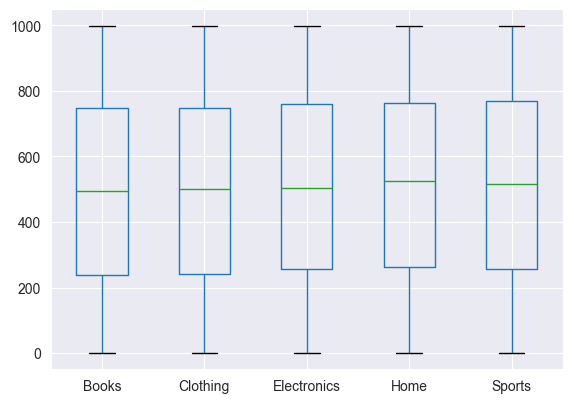

In [87]:
import matplotlib.pyplot as plt
import pandas as pd

df =pd.read_csv('catalog_products.csv')

df.boxplot(column='col_2',by='col_7')

plt.title('')
plt.suptitle('')
plt.xlabel('')
plt.ylabel('')

plt.grid(True)
plt.show()

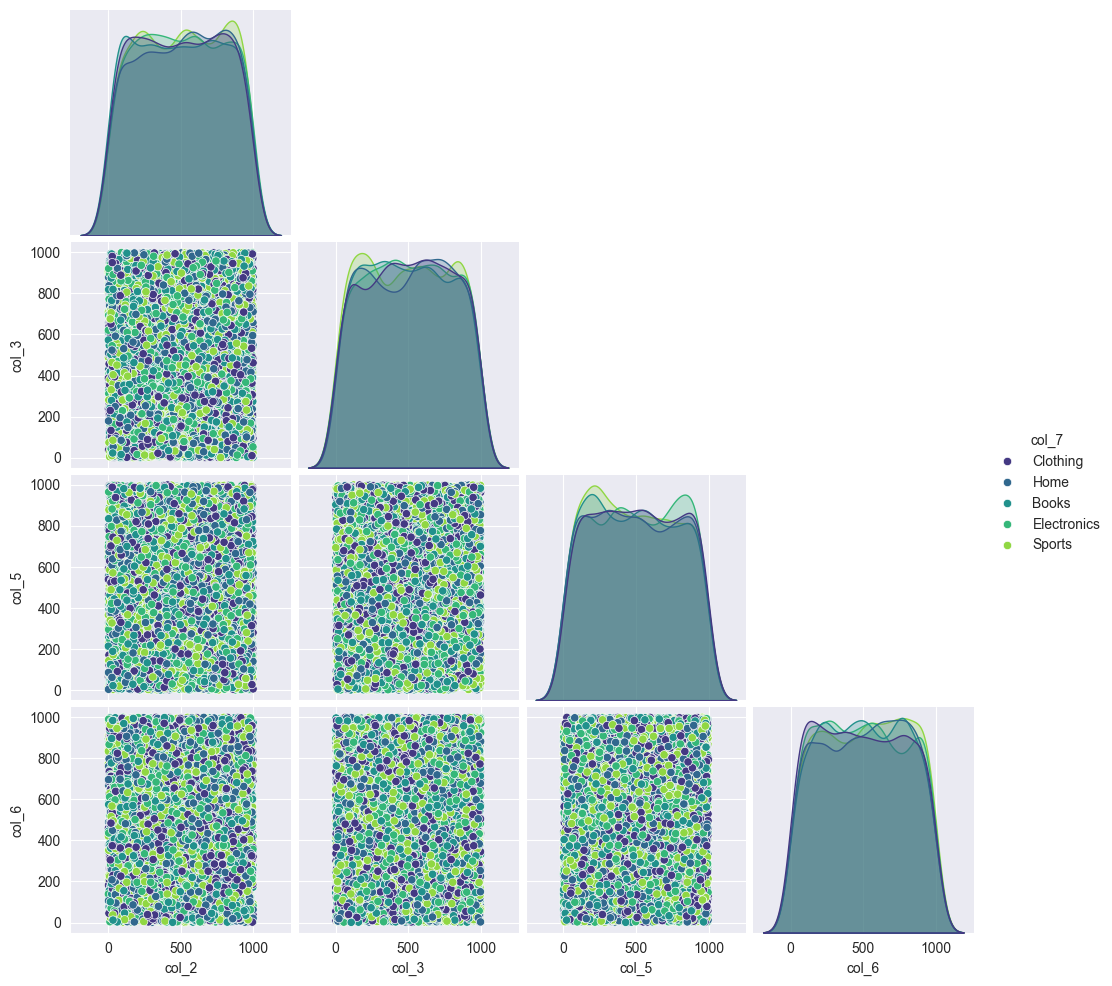

In [88]:
target_cols = [f'col_{i}' for i in range(2, 7)] + ['col_7']
df_subset = df[target_cols]
sns.pairplot(df_subset, hue='col_7', palette='viridis', corner=True)
plt.show()

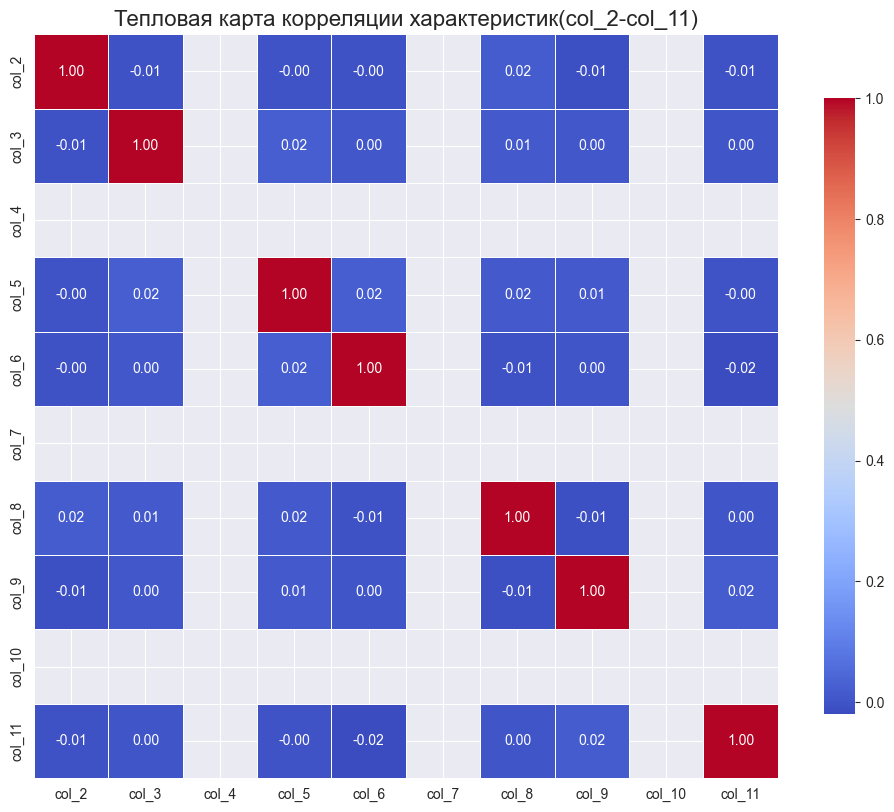

In [89]:
#13
target_cols = [f'col_{i}' for i in range(2,12)]

corr_matrix = df[target_cols].apply(pd.to_numeric, errors='coerce').corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True, cbar_kws={"shrink": .8})
plt.title('Тепловая карта корреляции характеристик(col_2-col_11)',fontsize=16)
plt.show()

In [90]:
#14
import matplotlib.pyplot as plt
import pandas as pd

df['total_value'] = df['col_2'] * df['col_3']
df['double_stock'] = df['col_4'] * 2
df['log_price'] = np.log(df['col_2'])
print(df[['col_2', 'col_3', 'col_4', 'total_value', 'double_stock', 'log_price']].head())
original_cols = [col for col in df.columns if col.startswith('col_')]
new_metrics = ['total_value','double_stock','log_price']
cols_to_save = original_cols + new_metrics

final_df = df[cols_to_save].copy()

final_df.to_excel('catalog_analysis.xlsx', index=False, engine='openpyxl')

print("Файл успешно создан")
print(f"Итоговое количество колонок:{len(final_df.columns)}")

   col_2  col_3        col_4  total_value            double_stock  log_price
0    762    303  Electronics       230886  ElectronicsElectronics   6.635947
1    190     34       Sports         6460            SportsSports   5.247024
2    711      2         Home         1422                HomeHome   6.566672
3    484    362        Books       175208              BooksBooks   6.182085
4    733    195         Home       142935                HomeHome   6.597146
Файл успешно создан
Итоговое количество колонок:53


In [91]:
#15
category_summary = df.groupby('col_7').agg(
    count=('col_2','count'),
    mean_price=('col_2','mean'),
    total_quantity=('col_3','sum'),
    mean_log_price=('log_price','mean')
).reset_index()

category_summary = category_summary.rename(columns={'col_7':'category'})

category_summary['mean_price'] = category_summary['mean_price'].round(2)
category_summary['mean_log_price'] = category_summary['mean_log_price'].round(2)

display(category_summary.head())

,category,count,mean_price,total_quantity,mean_log_price
0,Books,1994,494.01,982076,5.88
1,Clothing,1997,495.74,1008454,5.89
2,Electronics,2004,505.89,1009669,5.93
3,Home,1968,511.10,995489,5.94
4,Sports,2037,509.05,1008988,5.94


In [92]:
#16
idx = df.groupby('col_7')['col_2'].idxmax()

most_expensive = df.loc[idx, ['col_1','col_2','col_7']]

display(most_expensive)

,col_1,col_2,col_7
1117,Sports,999,Books
1019,Home,999,Clothing
1478,Sports,999,Electronics
3101,Clothing,999,Home
2890,Sports,999,Sports


In [93]:
#17
df['col_2'] = pd.to_numeric(df['col_2'], errors='coerce')
df['col_3'] = pd.to_numeric(df['col_3'], errors='coerce')

df['total_value'] = df['col_2'] * df['col_3']

top_10_value = df.sort_values(by='total_value', ascending=False).head(10).reset_index()
result = top_10_value[['col_1','col_2','col_3','total_value']]

display(result)

,col_1,col_2,col_3,total_value
0,Books,994,999,993006
1,Sports,993,997,990021
2,Clothing,994,992,986048
3,Home,988,981,969228
4,Electronics,997,971,968087
5,Electronics,986,979,965294
6,Electronics,997,968,965096
7,Sports,966,996,962136
8,Electronics,963,998,961074
9,Clothing,982,975,957450


,price_range,count
0,0-50,515
1,50-200,1457
2,200-500,2936
3,500-1000,5092
4,>1000,0


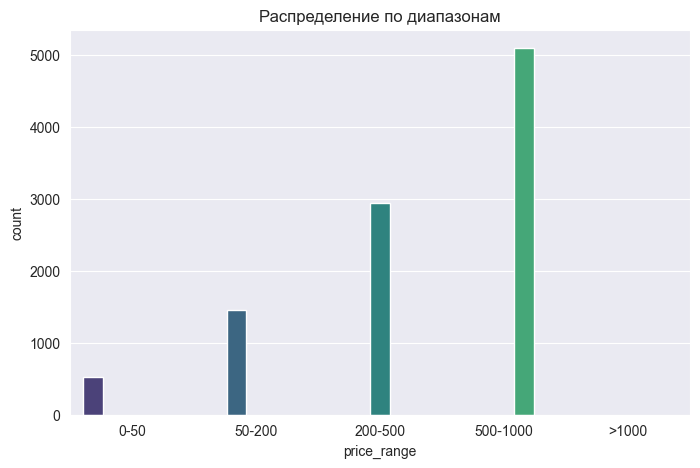

In [94]:
#18
bins = [0,50,200,500,1000,float('inf')]
labels = ['0-50','50-200','200-500','500-1000','>1000']

df['col_2'] = pd.to_numeric(df['col_2'], errors='coerce')
df['price_range'] = pd.cut(df['col_2'], bins=bins, labels=labels, right=False)

result = df['price_range'].value_counts(sort=False).reset_index(name='count')
display(result)

plt.figure(figsize=(8,5))
sns.countplot(data=df,x='price_range', hue='price_range', palette='viridis', legend=False)

plt.title('Распределение по диапазонам')
plt.show()

In [95]:
#19
df['col_2'] = pd.to_numeric(df['col_2'],errors='coerce')
df['col_3'] = pd.to_numeric(df['col_3'],errors='coerce')

df['total_values'] = df['col_2'] * df['col_3']
category_value = df.groupby('col_7')['total_values'].sum().reset_index()

category_value.columns=['category','total_stock_value']
category_value = category_value.sort_values('total_stock_value',ascending=False).reset_index(drop=True)

display(category_value)



,category,total_stock_value
0,Sports,511957866
1,Home,509060773
2,Electronics,506372840
3,Clothing,500261132
4,Books,485388939


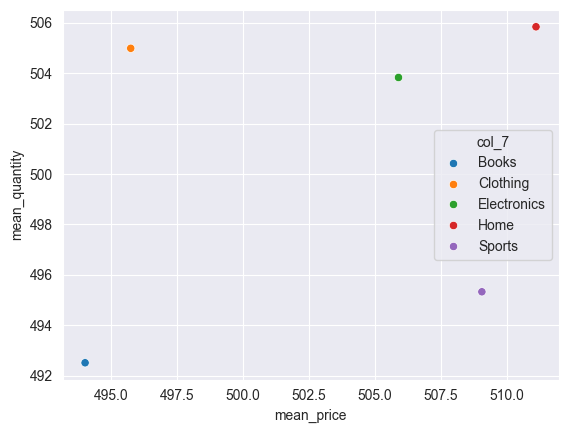

In [96]:
cat_stats = df.groupby('col_7').agg(
    mean_price=('col_2','mean'),
    mean_quantity=('col_3','mean')
).reset_index()

sns.scatterplot(
    data=cat_stats,
    x='mean_price',
    y='mean_quantity',
    hue='col_7'
)

plt.show()

,col_7,std_price
0,Books,293.28
1,Clothing,289.29
2,Sports,288.95
3,Home,288.70
4,Electronics,288.68


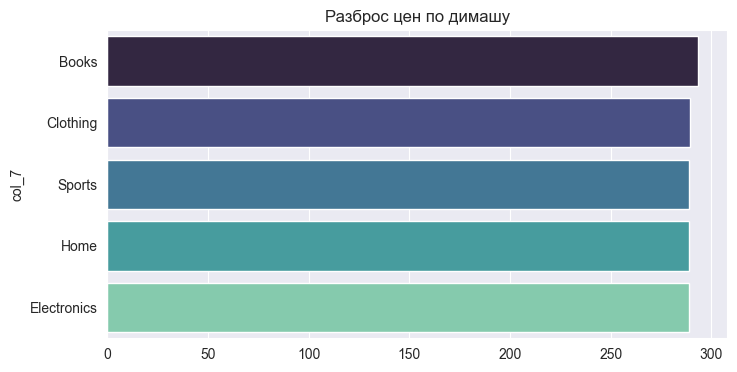

In [97]:
 #21
df['col_2'] = pd.to_numeric(df['col_2'],errors='coerce')
std_stats = df.groupby('col_7')['col_2'].std().dropna().sort_values(ascending=False)

display(std_stats.round(2).reset_index(name='std_price'))

plt.figure(figsize=(8,4))
sns.barplot(x=std_stats.values, y=std_stats.index, hue=std_stats.index, palette='mako', legend=False)
plt.title('Разброс цен по димашу')
plt.show()

In [98]:
#22
df['col_3'] = pd.to_numeric(df['col_3'], errors='coerce')

zero_stock = df[df['col_3'] == 0][['col_1','col_7','col_2']].head(10)

display(zero_stock)

,col_1,col_7,col_2


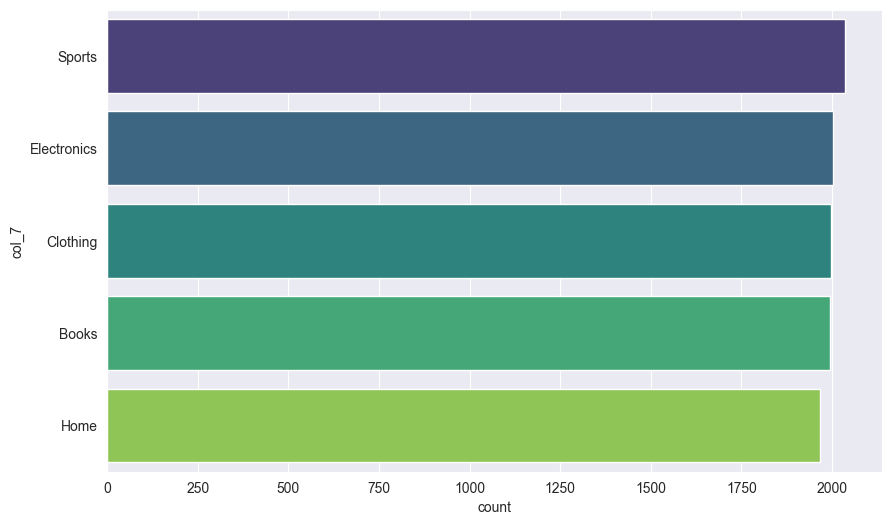

In [99]:
#23
counts = df.groupby('col_7').size().reset_index(name='count')
top_5 = counts.sort_values(by='count', ascending=False).head(5)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_5, x='count', y='col_7', hue='col_7', palette='viridis', legend=False)
plt.show()

      col_1  col_3
      Books    999
      Books    999
Electronics    999
   Clothing    998
Electronics    998
       Home    998
   Clothing    998
Electronics    998
   Clothing    998
       Home    998


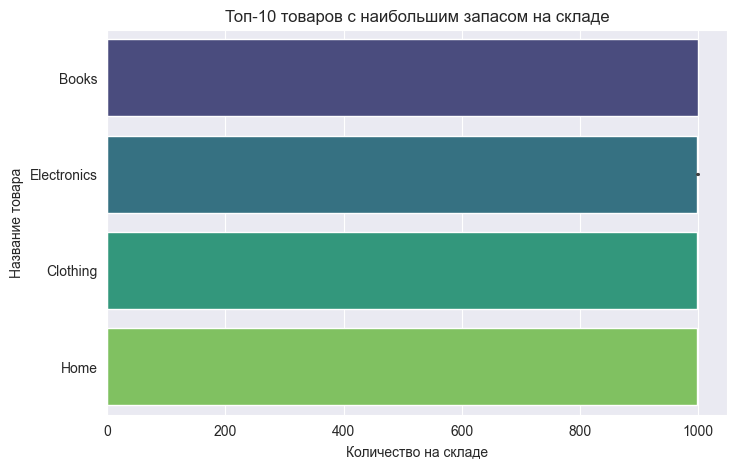

In [100]:
#24
# 1. Убеждаемся, что запасы — это числа, сортируем по убыванию и берем топ-10
df['col_3'] = pd.to_numeric(df['col_3'], errors='coerce')
top_10_stock = df.sort_values(by='col_3', ascending=False).head(10)[['col_1', 'col_3']]
# Выводим текстовую таблицу без номеров строк (как в примере)
print(top_10_stock.to_string(index=False))

# 2. Строим горизонтальный barplot (y - категории, x - значения)
plt.figure(figsize=(8, 5))
sns.barplot(data=top_10_stock, x='col_3', y='col_1', hue='col_1', palette='viridis',legend=False)

# Оформление
plt.title('Топ-10 товаров с наибольшим запасом на складе')
plt.xlabel('Количество на складе')
plt.ylabel('Название товара')
plt.show()

   category  0-50  50-200  200-500  500-1000
      Books   114     313      579       988
   Clothing   107     303      583      1004
Electronics   101     276      618      1009
       Home   105     264      563      1036
     Sports    88     301      593      1055


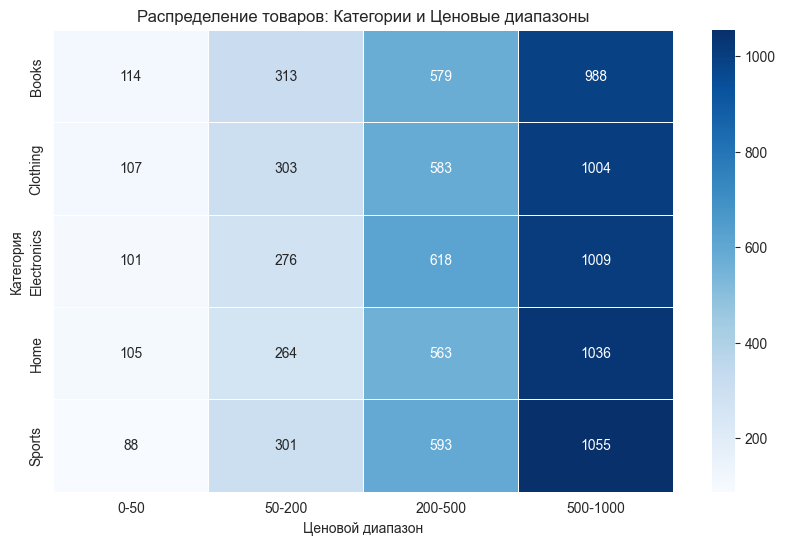

In [101]:
#25
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Приводим цены к числам и нарезаем на диапазоны
df['col_2'] = pd.to_numeric(df['col_2'], errors='coerce')
bins, labels = [0, 50, 200, 500, 1000, float('inf')], ['0-50', '50-200', '200-500', '500-1000', '>1000']
df['price_range'] = pd.cut(df['col_2'], bins=bins, labels=labels, right=False)

# 2. Создаем сводную таблицу
# aggfunc='size' считает количество строк, fill_value=0 заменяет пустоты на нули
pivot_df = df.pivot_table(index='col_7', columns='price_range', aggfunc='size', fill_value=0)

# 3. Готовим таблицу к выводу: сбрасываем индекс и убираем лишнее имя колонок
output_df = pivot_df.reset_index().rename(columns={'col_7': 'category'})
output_df.columns.name = None
print(output_df.to_string(index=False))

# 4. Строим Heatmap
plt.figure(figsize=(10, 6))

# Передаем оригинальный pivot_df (до reset_index), чтобы категории стали осью Y
# annot=True включает цифры в ячейках, fmt='d' делает их целыми, cmap задает цвет
sns.heatmap(pivot_df, annot=True, fmt='d', cmap='Blues', linewidths=.5)

plt.title('Распределение товаров: Категории и Ценовые диапазоны')
plt.xlabel('Ценовой диапазон')
plt.ylabel('Категория')
plt.show()

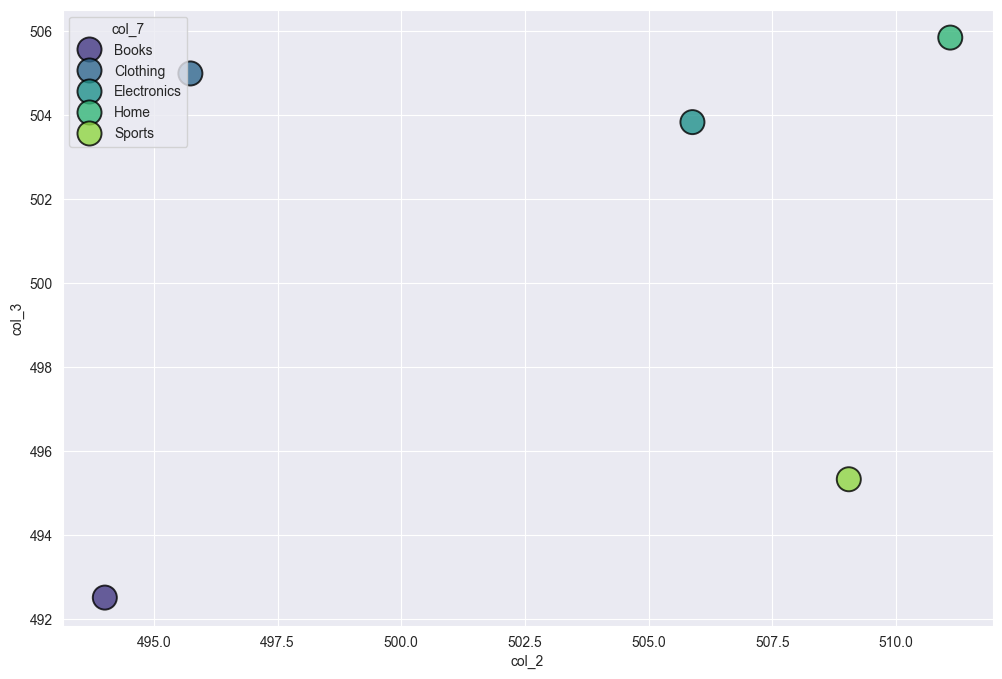

In [102]:
#36
category_analysis = df.groupby('col_7').agg({'col_2': 'mean', 'col_3': 'mean'}).reset_index()
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=category_analysis, x='col_2', y='col_3', hue='col_7', s=300, palette='viridis', edgecolor='black', alpha=0.8)
plt.show()

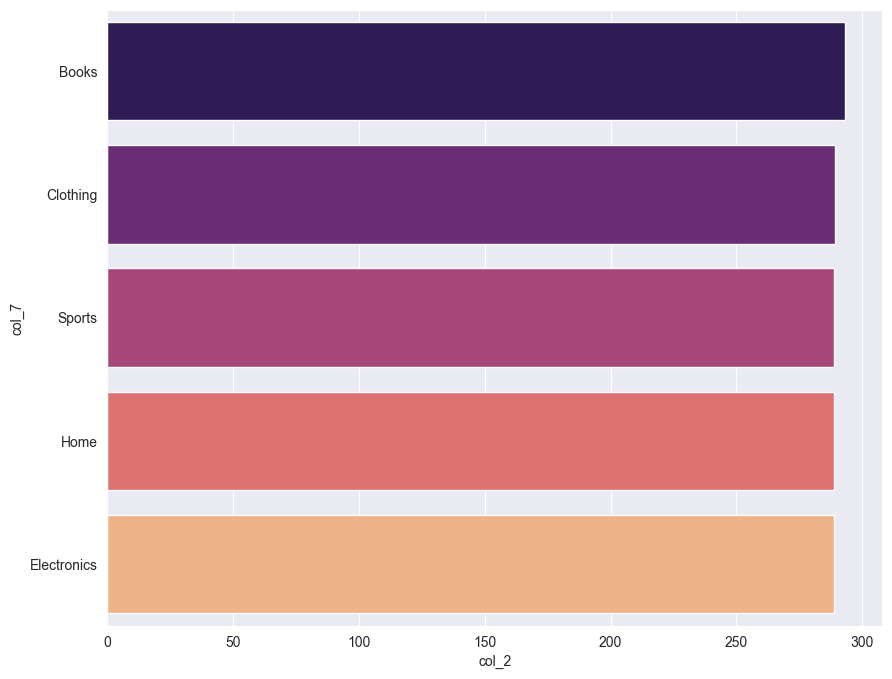

In [103]:
#37
m = df.groupby('col_7')['col_2'].std().reset_index()
m = m.sort_values(by='col_2', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(data=m, x='col_2', y='col_7', hue='col_7', palette='magma')
plt.show()

In [104]:
#38
n = df[df['col_3'] == 0]
b = n[['col_1', 'col_7', 'col_2']].head(10)
print(b)

Empty DataFrame
Columns: [col_1, col_7, col_2]
Index: []


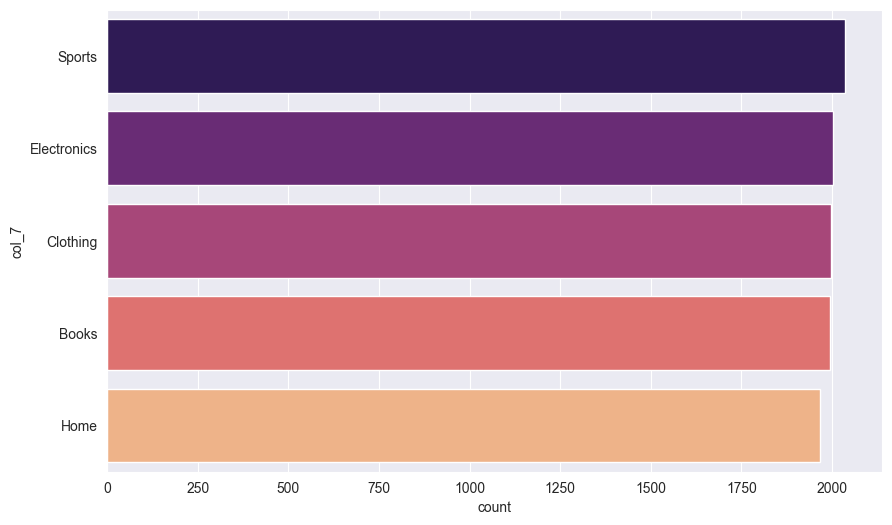

In [105]:
#39
v = df['col_7'].value_counts().head(5).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=v, x='count', y='col_7', hue='col_7', palette='magma')
plt.show()

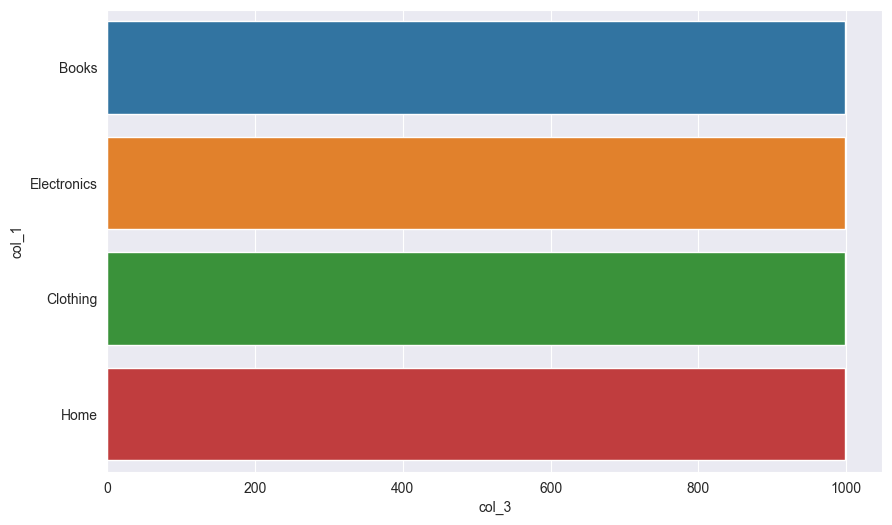

In [106]:
#40
c = df.sort_values(by='col_3', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=c, x='col_3', y='col_1', hue='col_1')
plt.show()

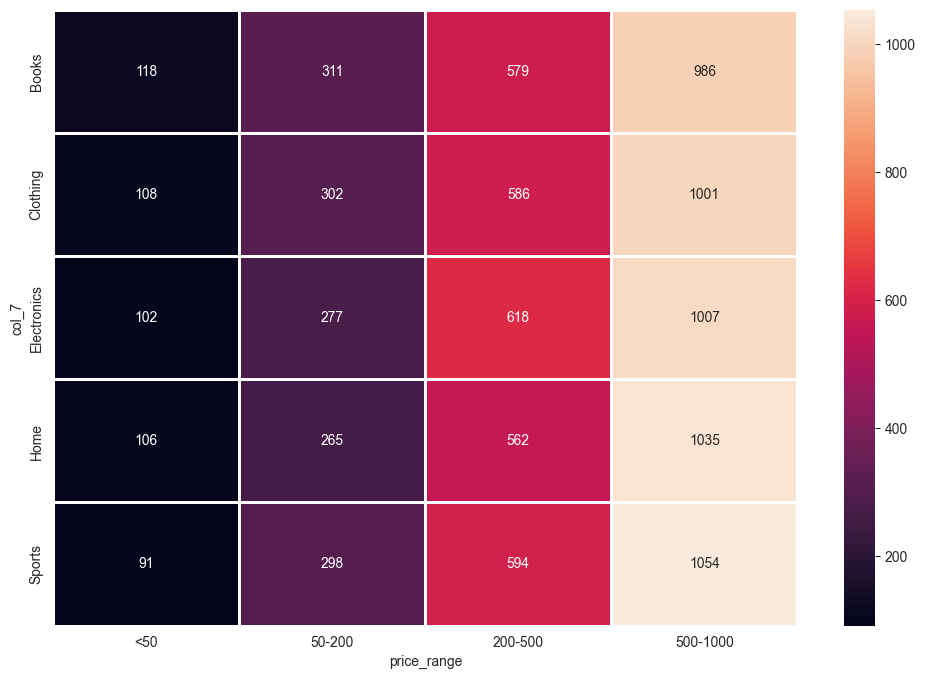

In [107]:
#41
bins = [0, 50, 200, 500, 1000, float('inf')]
labels = ['<50', '50-200', '200-500', '500-1000', '>1000']
df['price_range'] = pd.cut(df['col_2'], bins=bins, labels=labels, include_lowest=True)
heatmap_data = pd.crosstab(df['col_7'], df['price_range'])
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', linewidths=1)
plt.show()

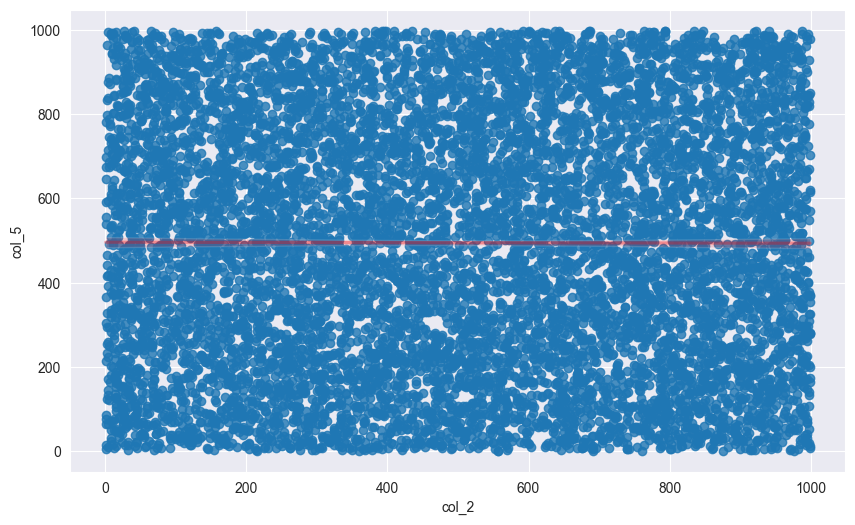

In [108]:
#42
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='col_2', y='col_5', line_kws={'alpha':0.3,'color':'red'})
plt.show()

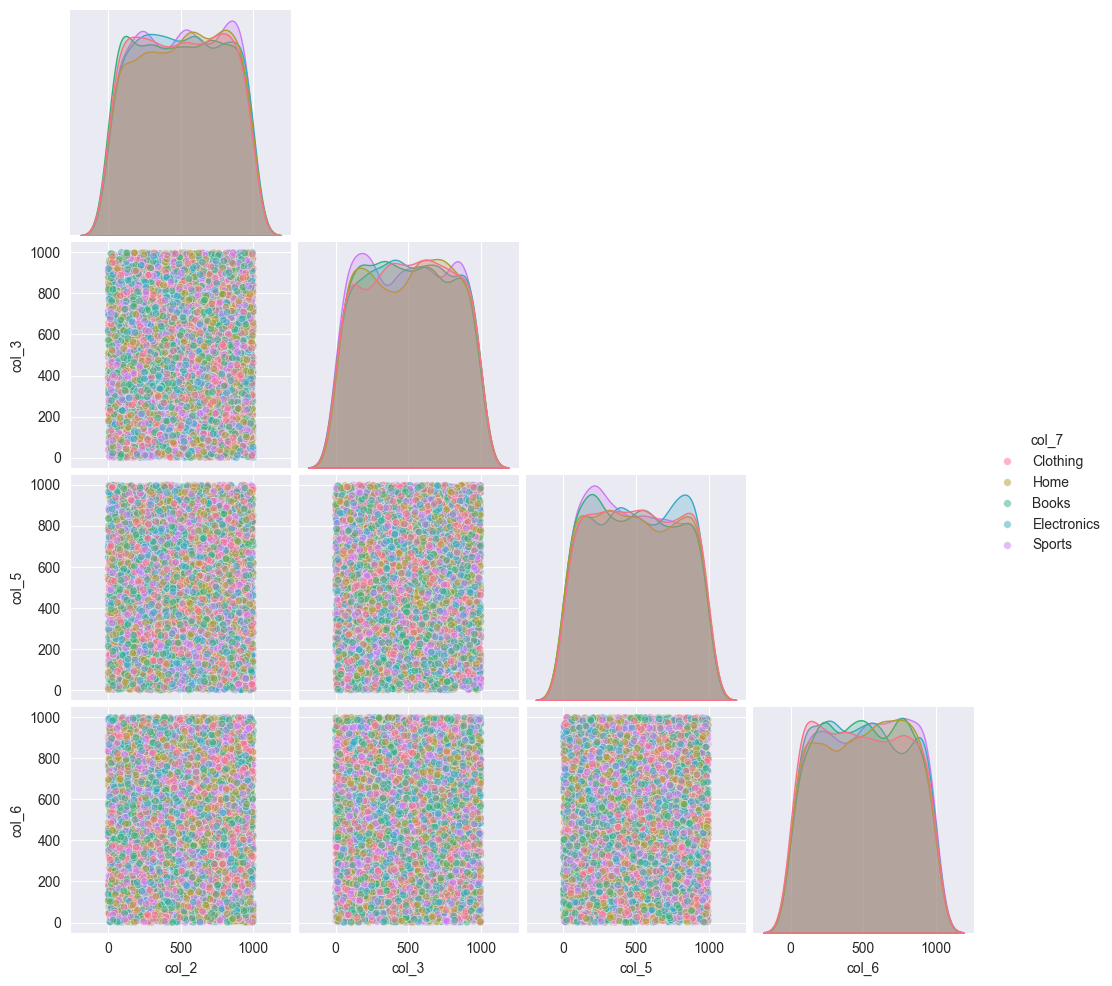

In [109]:
#43
l = ['col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7']
subset_df = df[l]
pair_grid = sns.pairplot(subset_df, hue='col_7', palette='husl', corner=True, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30})
plt.show()

In [110]:
#44
k2 = df['col_2'].mean() + 3 * df['col_2'].std()
k3 = df['col_3'].mean() + 3 * df['col_3'].std()
j = df[(df['col_2'] > k2) | (df['col_3'] > k3)]
print(j)

Empty DataFrame
Columns: [col_1, col_2, col_3, col_4, col_5, col_6, col_7, col_8, col_9, col_10, col_11, col_12, col_13, col_14, col_15, col_16, col_17, col_18, col_19, col_20, col_21, col_22, col_23, col_24, col_25, col_26, col_27, col_28, col_29, col_30, col_31, col_32, col_33, col_34, col_35, col_36, col_37, col_38, col_39, col_40, col_41, col_42, col_43, col_44, col_45, col_46, col_47, col_48, col_49, col_50, total_value, double_stock, log_price, price_range, total_values]
Index: []

[0 rows x 55 columns]


In [111]:
#45
category_summary = df.groupby('col_7').agg({'col_2': 'mean', 'col_3': 'sum'}).reset_index()

top_10_stock = df.sort_values(by='col_3', ascending=False).head(10)

top_10_value = df.sort_values(by='total_value', ascending=False).head(10)

file_name = 'catalog_final_report.xlsx'
with pd.ExcelWriter(file_name, engine='openpyxl') as writer:
    category_summary.to_excel(writer, sheet_name='Свод по категориям', index=False)
    top_10_stock.to_excel(writer, sheet_name='Топ-10 запас', index=False)
    top_10_value.to_excel(writer, sheet_name='Топ-10 стоимость', index=False)
    df.to_excel(writer, sheet_name='Полный каталог', index=False)